# Données topographiques (MNT / SRTM)

`DEM` télécharge un **Modèle Numérique de Terrain** SRTM (~30 m) sans clé
API, via les tuiles Skadi hébergées sur AWS. Il mosaïque les tuiles 1°×1°
et découpe le résultat à l'emprise demandée (EPSG:4326).

- `download(bbox, out_tif)` — récupère le GeoTIFF (bbox = `(ouest, sud, est, nord)` ou un `GeoDataFrame`)
- `info(tif)` — métadonnées et statistiques d'altitude
- `plot(tif)` — aperçu avec ombrage
- `hillshade` / `slope` / `aspect` — produits dérivés
- `reproject(tif, out, dst_crs)` — changement de projection

Exemple : la région de **Man** (ouest de la Côte d'Ivoire), le relief le
plus marqué du pays. Une petite emprise = une seule tuile à télécharger.

In [1]:
import logging
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # cartograpy est à la racine du dépôt
logging.basicConfig(level=logging.INFO, format="%(message)s")

import matplotlib.pyplot as plt
import cartograpy as cp
from cartograpy.data import DEM

dem = DEM(work_dir="_dem_cache")
BBOX = (-7.65, 7.25, -7.35, 7.55)  # autour de Man (ouest CIV)

C:\Users\Ordinateur\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\importlib\metadata\__init__.py:467: DeprecationWarning: Implicit None on return values is deprecated and will raise KeyErrors.
  return self.metadata['Version']


## Télécharger le MNT

Le premier appel télécharge la tuile depuis AWS ; les suivants sont servis
depuis le cache HTTP de `_dem_cache/`.

In [2]:
tif = dem.download(BBOX, out_tif="_dem_cache/man.tif")
tif

Téléchargement DEM:   0%|          | 0/1 [00:00<?, ?tuile/s]

Téléchargement DEM: 100%|██████████| 1/1 [00:08<00:00,  8.80s/tuile]

Téléchargement DEM: 100%|██████████| 1/1 [00:08<00:00,  8.81s/tuile]

WindowsPath('_dem_cache/man.tif')

In [3]:
meta = DEM.info(tif)
meta["stats"]

── Informations MNT : man.tif ──


  CRS           : EPSG:4326


  Dimensions    : 1081 × 1081 pixels


  Résolution    : 0.000278° × 0.000278°


  Emprise       : BoundingBox(left=-7.65013888888889, bottom=7.2498611111111115, right=-7.349861111111112, top=7.550138888888889)


  Nodata        : -32768.0


  Altitude      : 263.0 m → 1259.0 m (moy. 425.3 m, σ 171.7 m)


{'min': 263.0,
 'max': 1259.0,
 'moyenne': 425.3173116337102,
 'écart-type': 171.6508412614663}

## Aperçu rapide

`DEM.plot` superpose l'altitude (palette `terrain`) et un ombrage calculé
à la volée.

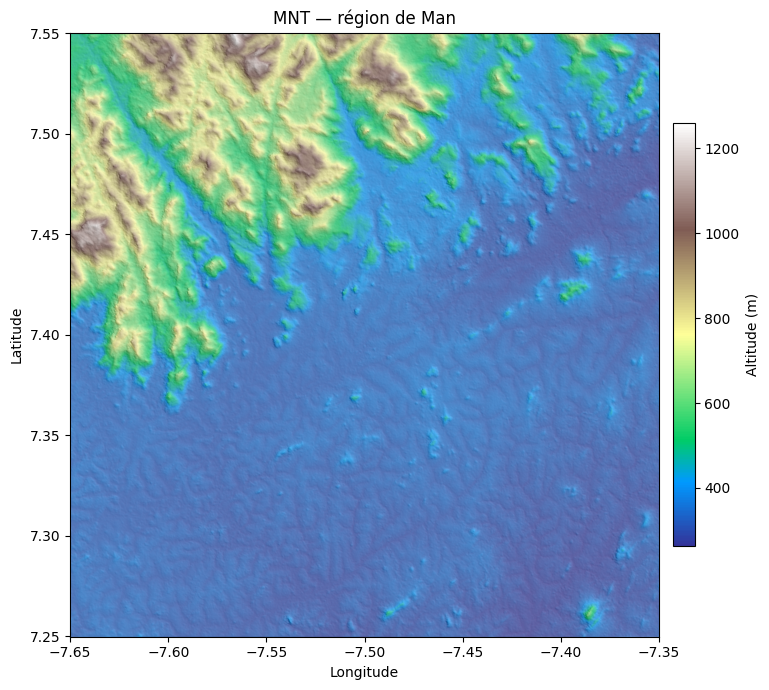

In [4]:
DEM.plot(tif, title="MNT — région de Man", figsize=(8, 7))

## Produits dérivés : ombrage, pente, orientation

Chaque fonction renvoie un tableau NumPy et, si `out_path` est fourni,
enregistre aussi un GeoTIFF.

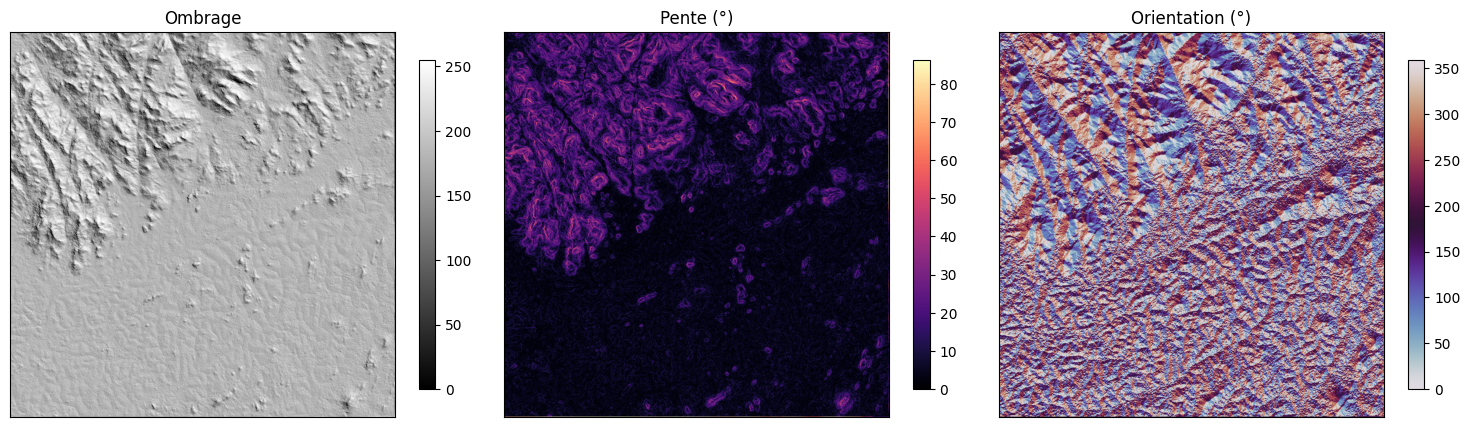

In [5]:
hs = DEM.hillshade(tif, out_path="_dem_cache/man_hillshade.tif")
slope = DEM.slope(tif, degrees=True)
aspect = DEM.aspect(tif)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, data, name, cmap in zip(
    axes,
    [hs, slope, aspect],
    ["Ombrage", "Pente (°)", "Orientation (°)"],
    ["gray", "magma", "twilight"],
):
    im = ax.imshow(data, cmap=cmap)
    ax.set_title(name)
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, shrink=0.7)
fig.tight_layout()

## Sur une carte cartograpy

`Map.add_raster` place le GeoTIFF dans une carte, où l'on peut superposer
des couches vectorielles (frontières, villes…).

📊 Centrage intelligent appliqué:


   Format: Personnalisé (N/A)


   Ratio figure: 1.50


   Ratio données: 1.00


   Étendue: [-7.76, -7.24, 7.23, 7.57]


C:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.
  warnings.warn(f"Provided CRS {bar_projection} uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.")


C:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.
  warnings.warn(f"Provided CRS {bar_projection} uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.")


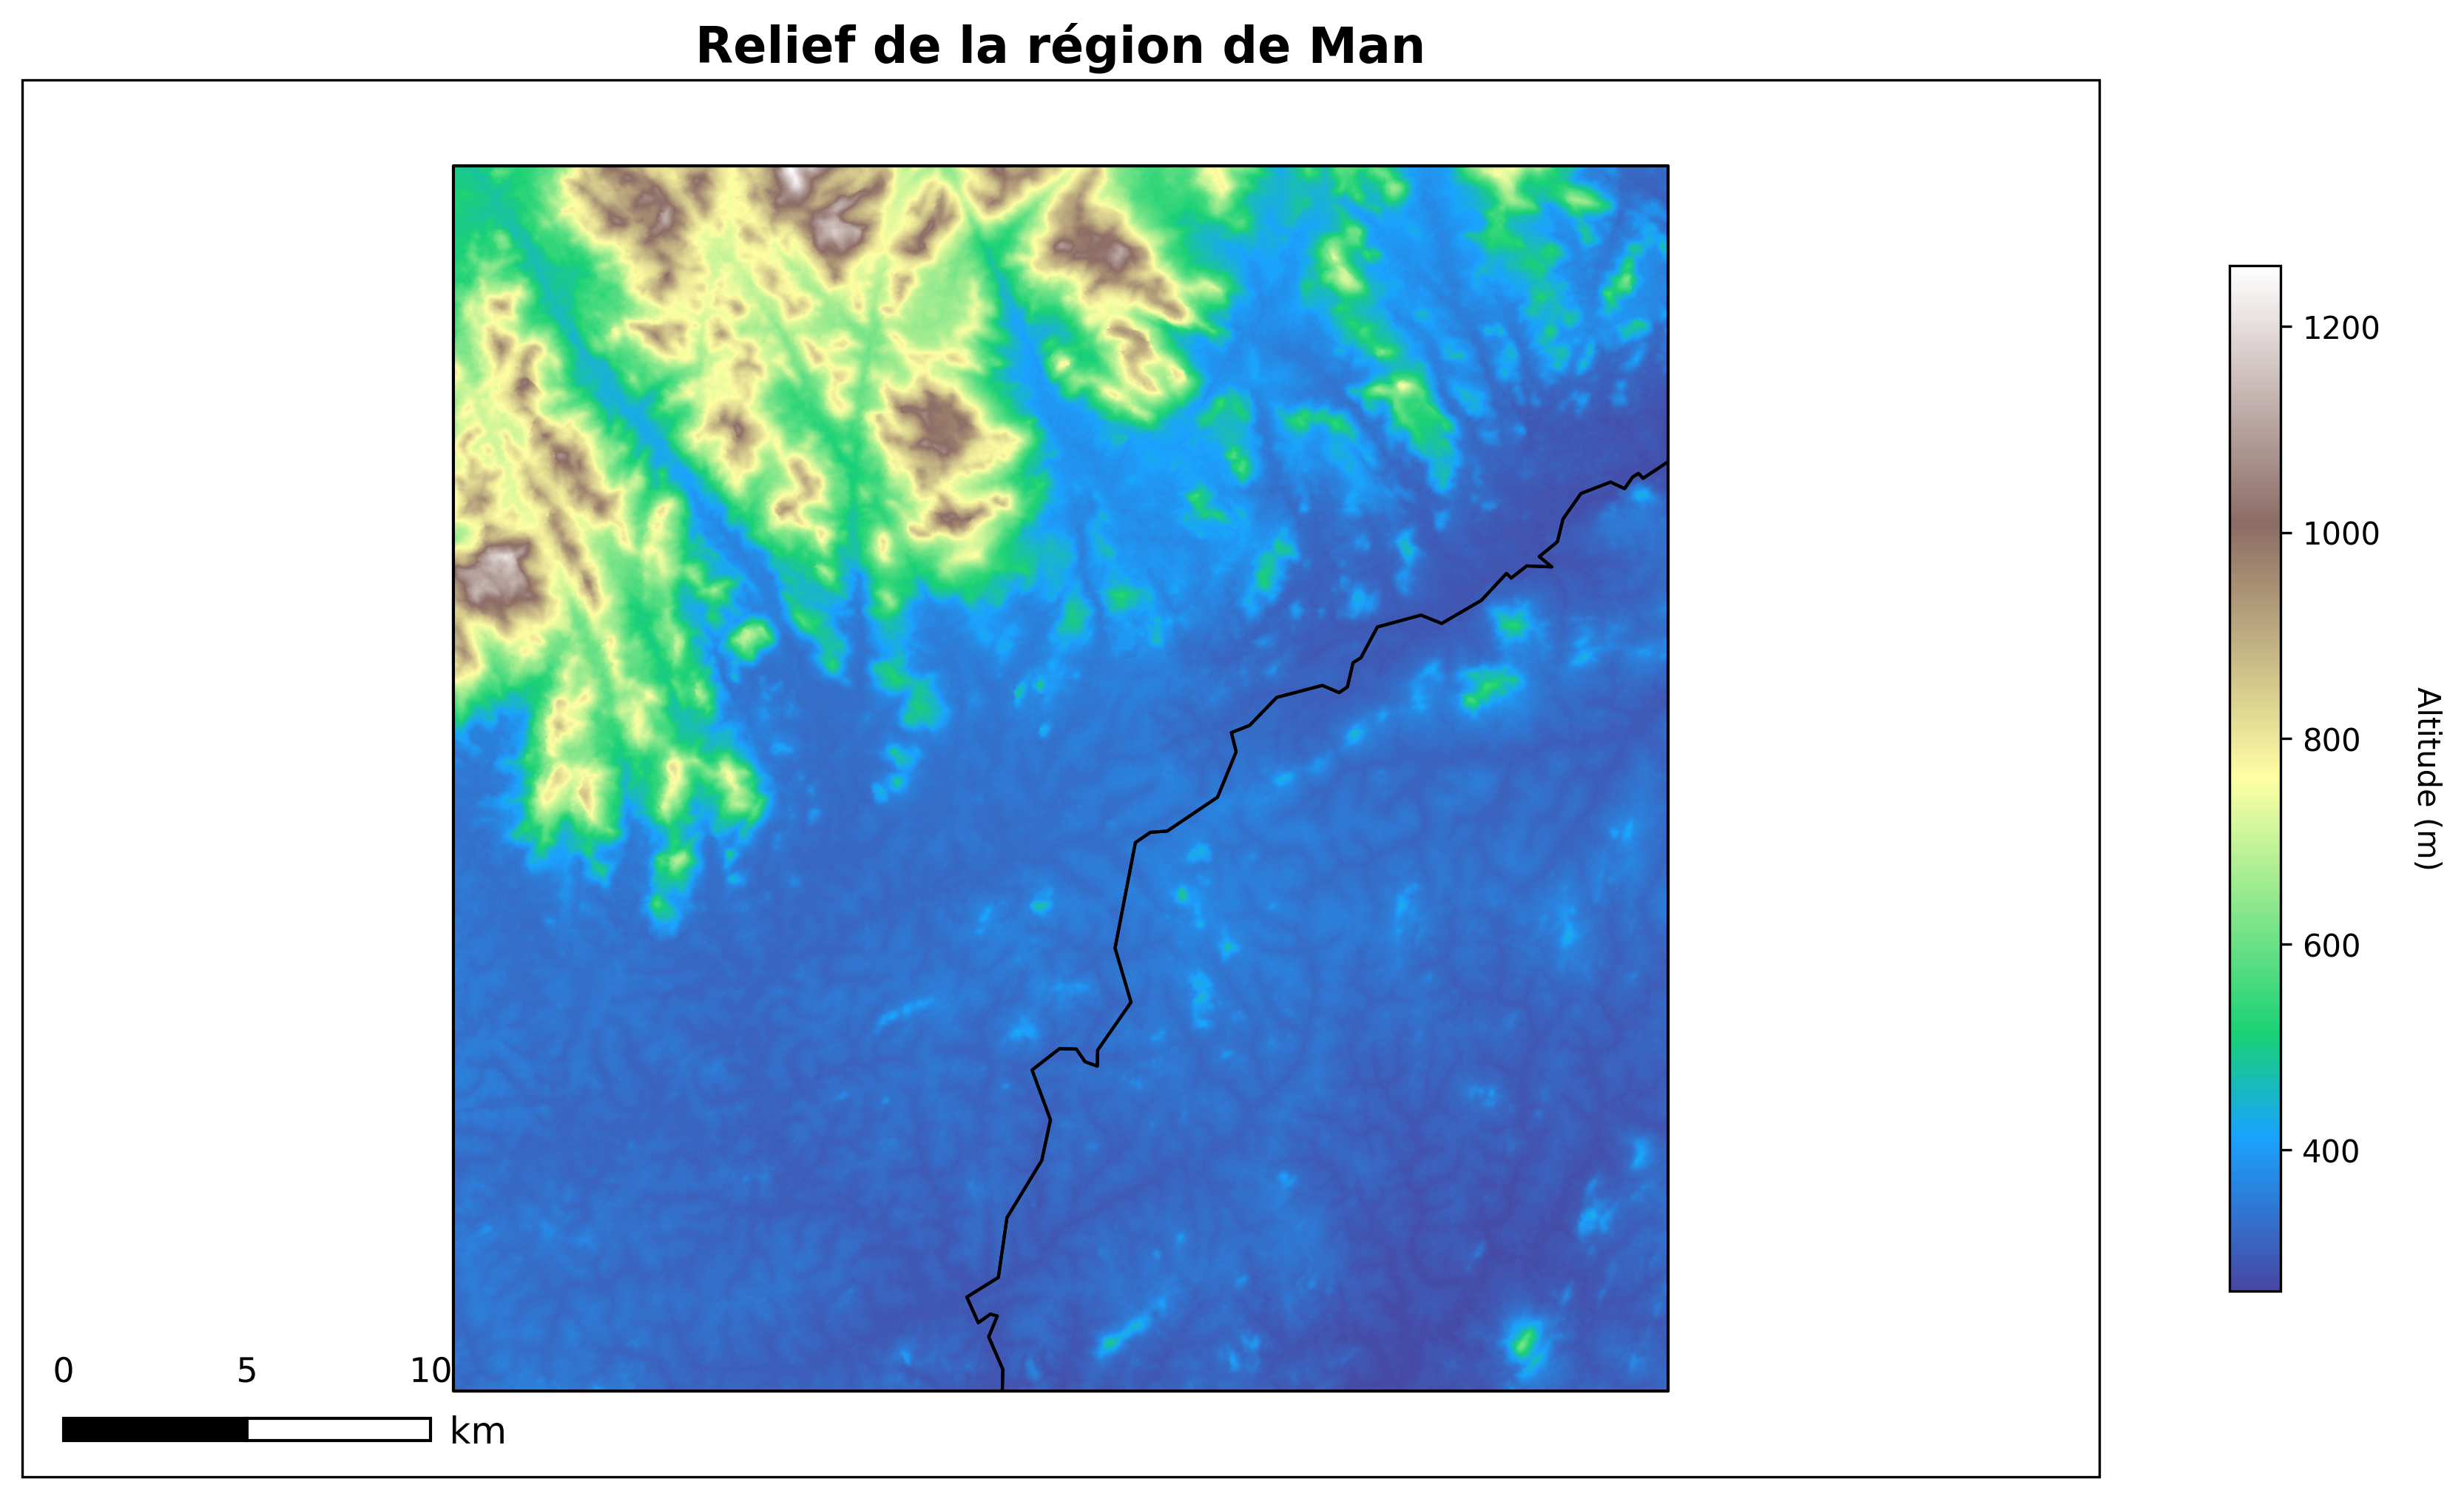

In [6]:
from cartograpy.data import Bound

man = Bound().get_admin("CIV", adm=2).set_crs("EPSG:4326").clip(BBOX)

m = cp.Map(title="Relief de la région de Man")
m.add_raster(raster_path=str(tif), cmap="terrain", alpha=0.9, title="Altitude (m)")
m.add_polygons(man, facecolor="none", edge_color="black", linewidth=1, alpha=1)
m.add_scale_bar()
m.show()

## Reprojeter

Le MNT est livré en EPSG:4326. Pour un calcul de pente/surface fiable ou un
fond web, on reprojette (ici en Web Mercator).

In [7]:
tif_3857 = DEM.reproject(tif, "_dem_cache/man_3857.tif", dst_crs="EPSG:3857")
DEM.info(tif_3857)["crs"]

── Informations MNT : man_3857.tif ──


  CRS           : EPSG:3857


  Dimensions    : 1086 × 1076 pixels


  Résolution    : 31.052225° × 31.052225°


  Emprise       : BoundingBox(left=-851609.5656089308, bottom=809197.9387653543, right=-818197.3716829633, top=842920.6549397045)


  Nodata        : -32768.0


  Altitude      : 263.0 m → 1257.0 m (moy. 425.3 m, σ 171.6 m)


'EPSG:3857'

## Relire le GeoTIFF plus tard

`cartograpy.data.load` ouvre n'importe quel raster (renvoie un
`rasterio.DatasetReader`).

In [8]:
from cartograpy.data import load

src = load(str(tif))
print("CRS :", src.crs, "| dimensions :", src.width, "x", src.height)
src.close()

CRS : EPSG:4326 | dimensions : 1081 x 1081
